# Lab 13

Description of lab:

Understand how to run and interpret models with lagged variables. Understand what serial correlation is and why it is important. Understand the concept of Stationarity and how to check for it. 

In [1]:
# RELEVANT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

# VISUALS
# Figure size
plt.rcParams['figure.figsize'] = [16,10]

# Text sizes
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize']= 12
plt.rcParams['font.size'] = 14

# Colors
plt.rcParams['legend.labelcolor'] = '#ffffff'
plt.rcParams['xtick.labelcolor'] = '#ffffff'
plt.rcParams['ytick.labelcolor'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['axes.titlecolor'] = '#ffffff'
plt.rcParams['axes.edgecolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'
plt.rcParams['figure.facecolor'] = '#1f1f1f'
plt.rcParams['axes.facecolor'] = '#1f1f1f'

# Graph colors
from cycler import cycler

diverse = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a', '#b15928', '#a6cee3', '#b2df8a', '#fb9a99']
greens = ['#2ca02c', '#4daf4a', '#45a05a', '#60bd68', '#5cb85c', '#6ba981', '#75bb6f', '#6dae64', '#4c9a5f']
blues = ['#1f78b4', '#377eb8', '#3182bd', '#4292c6', '#5aaed6', '#6baed6', '#7ba3df', '#92b3e4', '#a6bddb']
reds = ['#e41a1c', '#d73027', '#a50026', '#f46d43', '#d73027', '#fdae61', '#fee08b', '#fee08b', '#d73027']

plt.rcParams['axes.prop_cycle'] = cycler(color = diverse)

# Display max columns, pandas dataframes
pd.set_option('display.max_columns', None) 

### Distributed lag models

Simple and intuitive time series: distributed lag models. We have a y-variable (or endogenous variable) which we model on an x-variable and its lags. Can be written as: $y_t = \alpha + \delta_0x_t + \delta_1x_{t-1} + \delta_2x_{t-2} + u$

### Serial correlation

If we want correct standard errors, and in turn inference on the time series, then we have to take into account possible serial correlation (autocorrelation) in the error term. Serial correlation is defined as: $corr(u_t, u_s|X), t \ne s$. There is correlation over time between the different error terms. Intuitively, if we look at the residuals of regression, then without serial correlation they should look random (centered around 0, sometimes a bit positive, sometimes a bit negative, but no recognizeable pattern).

##### Log transformation

Sometimes a log transfromation is done to make data more linear (especially data that is subject to steady growth rates over time) or more normal. If both sides of an equation is transformed, it can make the results easier to interpret (can be interpreted as elasticity, a percent change in one variable is correlated to a percent change in another). Remember: to log-transform a variable, all values in a series MUST be positive and non-zero.

##### Dummy variables in time series regression

Dummy variables can be included in time series regression. 

##### Trends

Often we want to model a trend in data. A linear trend can be written as: $y_t = \alpha + \beta \cdot t + u_t$. This can be simulated in python:

In [2]:
T = 100
u_t = np.random.normal(0, 1, T)
t = np.arange(0, T, 1)
alpha = 2.5
beta = .3
y_t = alpha + beta * t + u_t

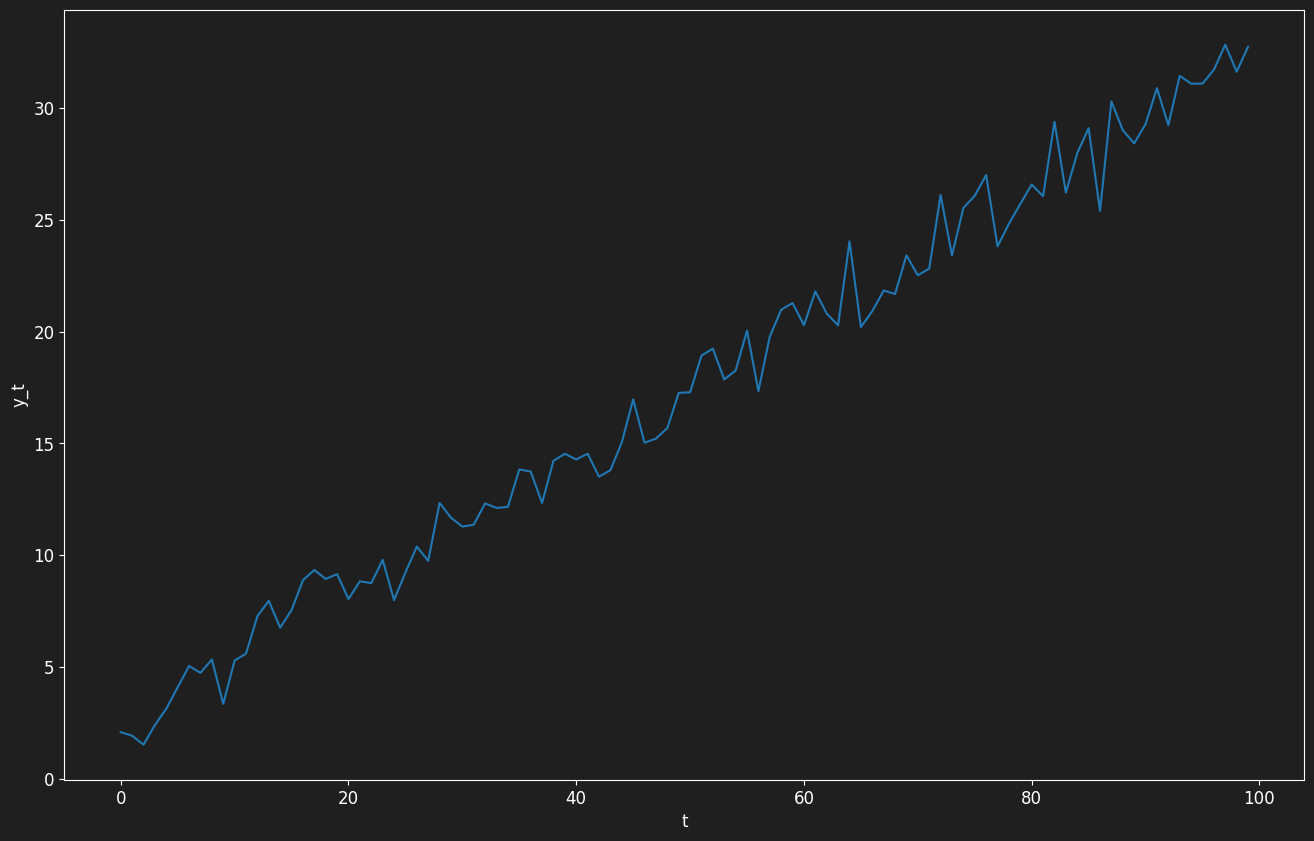

In [3]:
fig, ax = plt.subplots()
ax.plot(t, y_t)
ax.set_xlabel('t')
ax.set_ylabel('y_t')
plt.show()

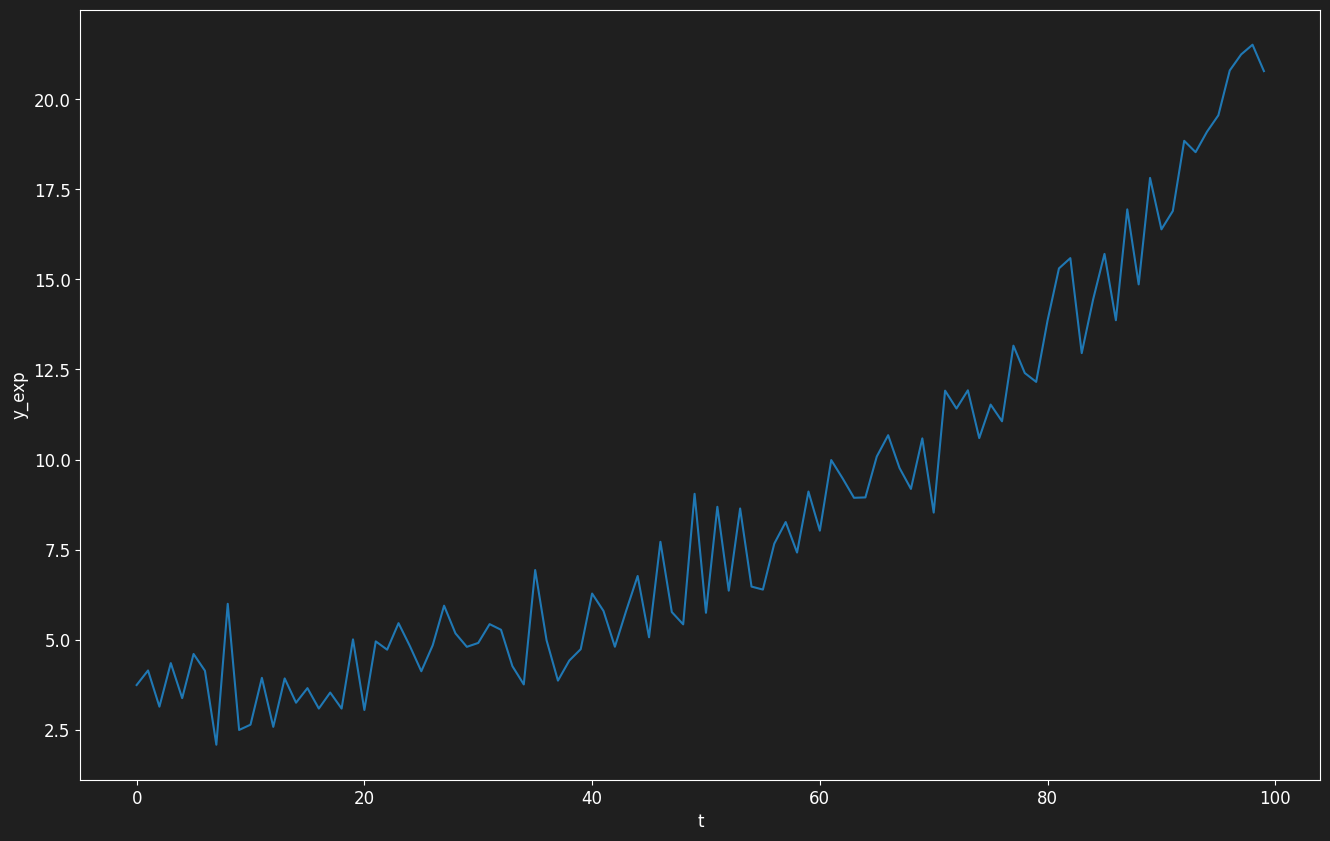

In [4]:
# If log(y_t) is modeled, we get an exponential trend (constant rate of growth over time, instead of a constant absolute increase over time)
beta = 0.03 # Exponential coefficient, rate of 3% per year.
u_t = np.random.normal(0, 1, T)

y_exp = alpha + np.exp(beta * t) + u_t

fig, ax = plt.subplots()
ax.plot(t, y_exp)
ax.set_xlabel('t')
ax.set_ylabel('y_exp')
plt.show()

### A little bit about the Nordic electricity market

In [5]:
#Wind production from Sweden and Denmark (in MWh)
wind_prod = pd.read_csv("http://jmaurit.github.io/norwayeconomy/data_series/dk_se_wind_data.csv")

#The price of power (on the day-ahead market) (EUR/MWh)
elspot = pd.read_csv("http://jmaurit.github.io/norwayeconomy/data_series/elspot.csv")

In [6]:
# Format the date variable for each df to be datetime format:
wind_prod['date'] = pd.to_datetime(wind_prod['date'], format = '%Y-%m-%d')
elspot['date'] = pd.to_datetime(elspot['date'], format = '%Y-%m-%d')

In [7]:
# Limit the series to data for the two Danish price areas: DK1 and DK2, and merge the datasets:
DK_df = wind_prod[['date', 'DK1', 'DK2']].merge(elspot[['date', 'DK1', 'DK2']], on = 'date', how = 'inner')
DK_df.columns =  ['date', 'DK1_wind', 'DK2_wind', 'DK1_price', 'DK2_price']
DK_df

,date,DK1_wind,DK2_wind,DK1_price,DK2_price
0,2013-01-01,20882,11388,4077,4089.0
1,2013-02-01,9254,5969,3940,4020.0
2,2013-03-01,13550,6160,4033,4158.0
3,2013-04-01,4965,2115,4282,4355.0
4,2013-05-01,7106,991,3682,3740.0
...,...,...,...,...,...
67,2018-08-01,2489,1775,5569,5684.0
68,2018-09-01,3017,1609,4989,5179.0
69,2018-10-01,32970,6256,4748,5090.0
70,2018-11-01,31766,4920,5404,5468.0


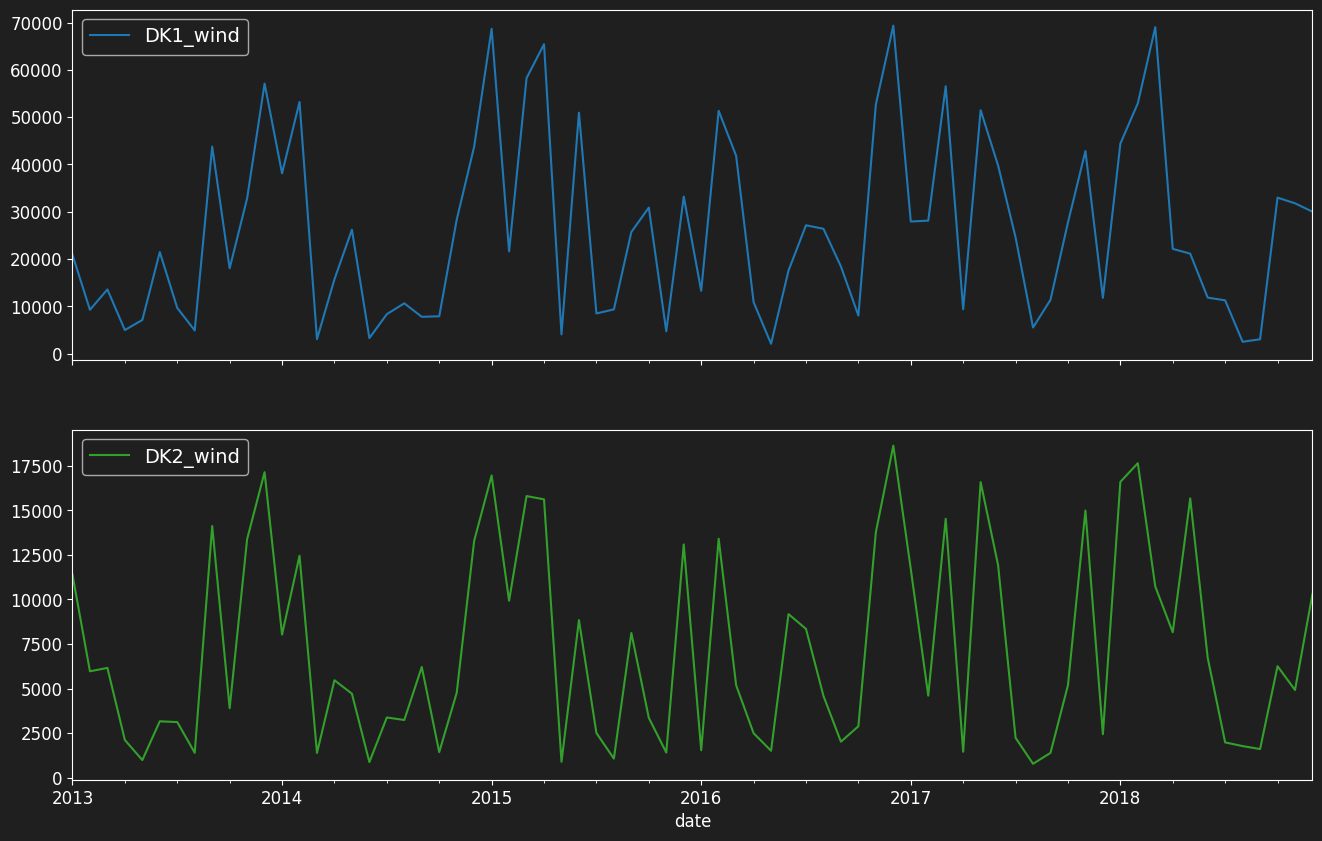

In [8]:
# Plotting the wind power over time:
DK_df[['date', 'DK1_wind', 'DK2_wind']].set_index('date').plot(subplots = True)
plt.show()

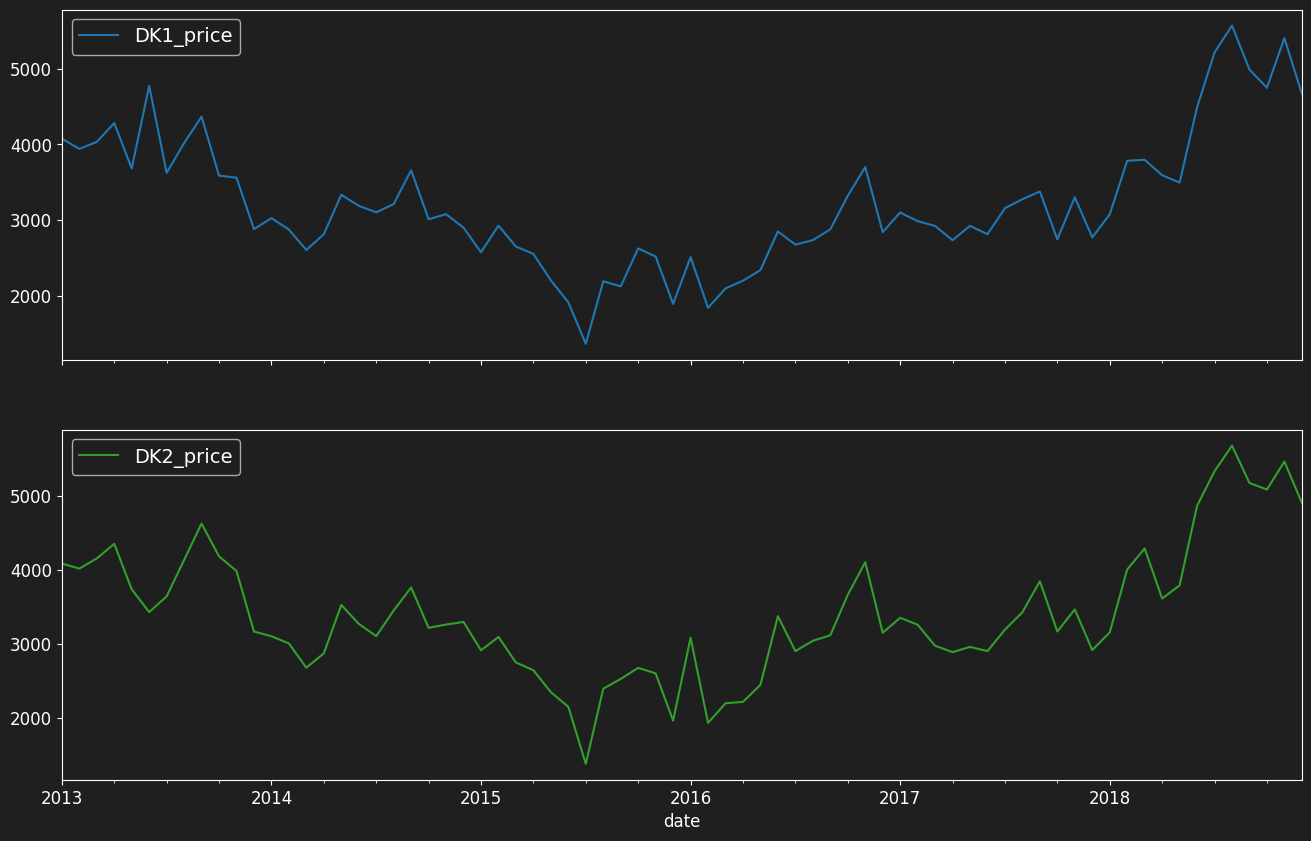

In [9]:
# Plotting the prices:
DK_df[['date', 'DK1_price', 'DK2_price']].set_index('date').plot(subplots = True)
plt.show()

In [10]:
# Run a simple linear regression to try to explain prices in DK1 based on wind power production in both areas and the price in DK2:
static_mod0 = smf.ols('DK1_price ~ DK2_price + DK1_wind + DK2_wind', data = DK_df).fit()
static_mod0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              DK1_price   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     306.0
Date:                Fri, 08 Dec 2023   Prob (F-statistic):           2.10e-39
Time:                        19:54:35   Log-Likelihood:                -492.67
No. Observations:                  72   AIC:                             993.3
Df Residuals:                      68   BIC:                             1002.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.0895    123.769      0.114      0.910    -232.888     261.067
DK2_price      0.9599      0.032     29.634      0.000       0.895       1.025
DK1_wind      -0.0008      0.003     -0.279      0.781      -0.006       0.005
DK2_wind      -0.0044      0.010     -0.459      0.648      -0.023       0.015
==============================================================================
Omnibus:                       91.981   Durbin-Watson:                   1.685
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1884.145
Skew:                           3.656   Prob(JB):                         0.00
Kurtosis:                      26.970   Cond. No.                     1.51e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### What is wrong with the regression?

DK2 price is a strong predictor of DK1 prices (Like we could expect from the graph above). R-squared is very high (indicating a good fit). Wind power does not seem to have a 'statistically significant' effect on prices. The things that are in fact wrong with this regression:
1. The DK1 price series is probably not stationary. Stationarity is a key concept in time series and forecasting.
2. Including DK2 price as a predictor probably does not make sense, since prices are co-determined at the same time in the day ahead market. By including DK2 we are getting a particularly good fit, but we are not estimating a particularily useful model. 
3. Dynamics have not been taken into account in the time series, like autocorrelation in the price series. 
4. The wind power coefficients are not 'statistically significant', but that does not mean that we should discount the estimated coefficients. This is very aggregated data, and having more data at a higher frequency may give different results. 

### Hourly data and stationarity

In [11]:
# Dealing with two of the problems: aggregated data and stationarity. Using hourly data:
wt_data = pd.read_csv("http://jmaurit.github.io/analytics/labs/data/wt_data2.csv")

# Pulling out relevant columns into separate df:
DK_df2 = wt_data[['time', 'hour', 'wind_DK1', 'wind_DK2', 'DK1EurMW', 'DK2EurMW']].copy()

In [12]:
DK_df2

,time,hour,wind_DK1,wind_DK2,DK1EurMW,DK2EurMW
0,2016-01-01 00:00:00,00 - 01,1314.0,113.0,1639.0,1639.0
1,2016-01-01 01:00:00,01 - 02,1267.0,98.0,1604.0,1604.0
2,2016-01-01 02:00:00,02 - 03,1159.0,74.0,1574.0,1574.0
3,2016-01-01 03:00:00,03 - 04,1160.0,61.0,1557.0,1557.0
4,2016-01-01 04:00:00,04 - 05,1069.0,47.0,1547.0,1547.0
...,...,...,...,...,...,...
26299,2018-12-31 19:00:00,19 - 20,3335.0,800.0,4751.0,4751.0
26300,2018-12-31 20:00:00,20 - 21,3147.0,865.0,4582.0,4582.0
26301,2018-12-31 21:00:00,21 - 22,2859.0,902.0,4303.0,4303.0
26302,2018-12-31 22:00:00,22 - 23,2708.0,792.0,3854.0,3854.0


In [13]:
DK_df2['time'] = pd.to_datetime(DK_df2['time'], format = '%Y-%m-%d %H:%M:%S')

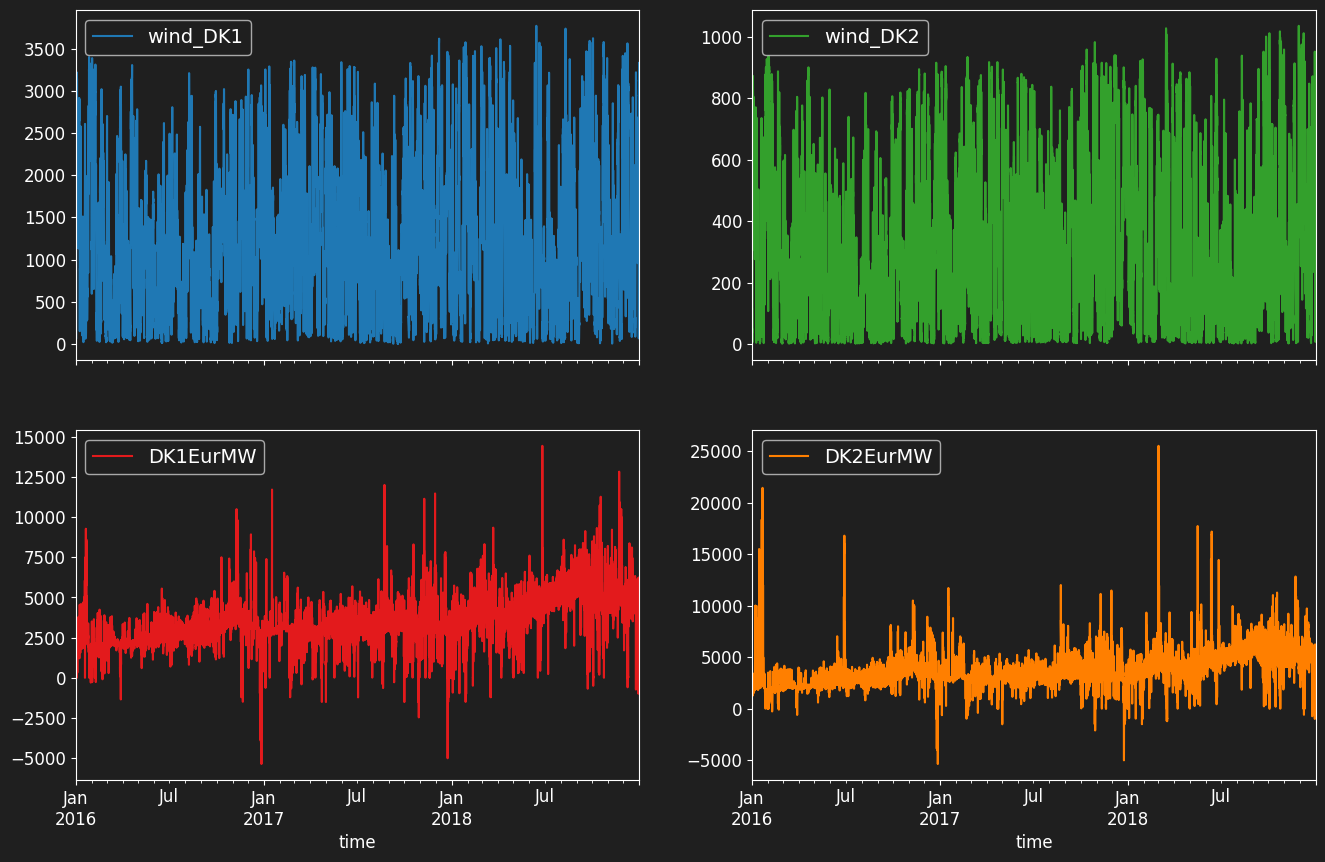

In [14]:
DK_df2[['time', 'wind_DK1', 'wind_DK2', 'DK1EurMW', 'DK2EurMW']].set_index('time').plot(subplots = True, layout = (2, 2))
plt.show()

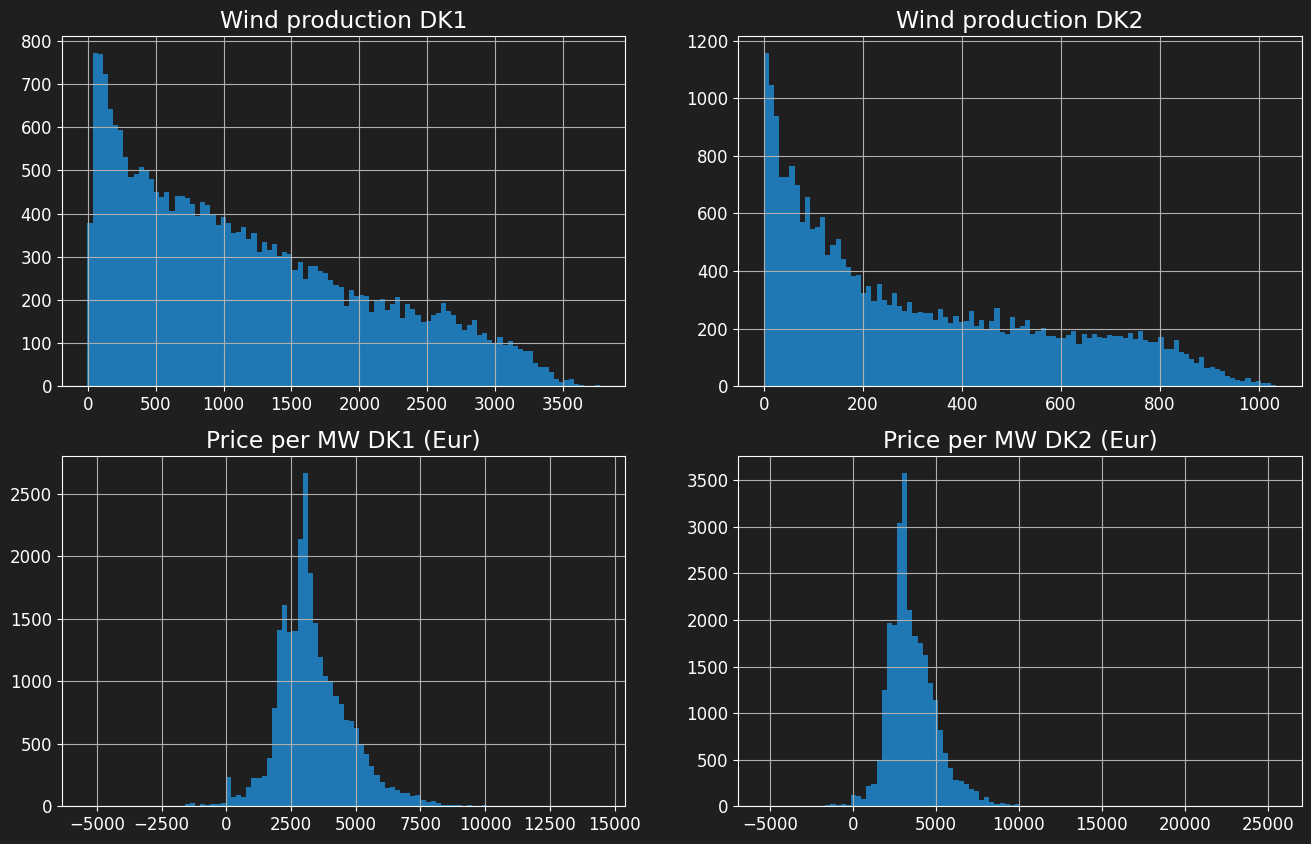

In [15]:
fig, ax = plt.subplots(2, 2)
DK_df2['wind_DK1'].hist(bins = 100, ax = ax[0, 0])
ax[0, 0].set_title('Wind production DK1')
DK_df2['wind_DK2'].hist(bins = 100, ax = ax[0, 1])
ax[0, 1].set_title('Wind production DK2')
DK_df2['DK1EurMW'].hist(bins = 100, ax = ax[1, 0])
ax[1, 0].set_title('Price per MW DK1 (Eur)')
DK_df2['DK2EurMW'].hist(bins = 100, ax = ax[1, 1])
ax[1, 1].set_title('Price per MW DK2 (Eur)')
plt.show()

##### Distributed lag model

In [16]:
# Make sure the data is sorted by time correctly and index by time:
DK_df2.sort_values('time', inplace = True)
DK_df2.set_index('time', inplace = True)

In [17]:
DK_df2['wind_DK1_l1'] = DK_df2['wind_DK1'].shift(freq = '1H') # Shift 1 hour
DK_df2['wind_DK1_l2'] = DK_df2['wind_DK1'].shift(freq = '2H') # Shift 2 hours
DK_df2['wind_DK1_l3'] = DK_df2['wind_DK1'].shift(freq = '3H') # Shift 3 hours

In [18]:
DK_df2

,hour,wind_DK1,wind_DK2,DK1EurMW,DK2EurMW,wind_DK1_l1,wind_DK1_l2,wind_DK1_l3
time,,,,,,,,
2016-01-01 00:00:00,00 - 01,1314.0,113.0,1639.0,1639.0,NaN,NaN,NaN
2016-01-01 01:00:00,01 - 02,1267.0,98.0,1604.0,1604.0,1314.0,NaN,NaN
2016-01-01 02:00:00,02 - 03,1159.0,74.0,1574.0,1574.0,1267.0,1314.0,NaN
2016-01-01 03:00:00,03 - 04,1160.0,61.0,1557.0,1557.0,1159.0,1267.0,1314.0
2016-01-01 04:00:00,04 - 05,1069.0,47.0,1547.0,1547.0,1160.0,1159.0,1267.0
...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,19 - 20,3335.0,800.0,4751.0,4751.0,3265.0,3120.0,3013.0
2018-12-31 20:00:00,20 - 21,3147.0,865.0,4582.0,4582.0,3335.0,3265.0,3120.0
2018-12-31 21:00:00,21 - 22,2859.0,902.0,4303.0,4303.0,3147.0,3335.0,3265.0


In [19]:
# Creating a simple model of prices in DK1 on wind power and its lagged variables using OLS:
dlmod1 = smf.ols('DK1EurMW ~ wind_DK1 + wind_DK1_l1 + wind_DK1_l2 + wind_DK1_l3', data = DK_df2).fit()
dlmod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               DK1EurMW   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     750.9
Date:                Fri, 08 Dec 2023   Prob (F-statistic):               0.00
Time:                        19:55:54   Log-Likelihood:            -2.2670e+05
No. Observations:               26289   AIC:                         4.534e+05
Df Residuals:                   26284   BIC:                         4.534e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3973.3844     13.982    284.181      0.000    3945.979    4000.790
wind_DK1       -0.3389      0.083     -4.103      0.000      -0.501      -0.177
wind_DK1_l1     0.0098      0.151      0.065      0.948      -0.286       0.306
wind_DK1_l2     0.0509      0.151      0.337      0.736      -0.245       0.347
wind_DK1_l3    -0.2415      0.083     -2.924      0.003      -0.403      -0.080
==============================================================================
Omnibus:                     2799.785   Durbin-Watson:                   0.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6120.339
Skew:                           0.664   Prob(JB):                         0.00
Kurtosis:                       4.956   Cond. No.                     4.96e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.96e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### Stationarity and persitence

In [20]:
# I will run a regression of the price series on its own lag (autoregressive (AR) model).
# Making a lagged variable for the price in DK1:
DK_df2['DK1EurMW_l1'] = DK_df2['DK1EurMW'].shift(freq = '1H') # Shift 1 hour
DK_df2.head()

,hour,wind_DK1,wind_DK2,DK1EurMW,DK2EurMW,wind_DK1_l1,wind_DK1_l2,wind_DK1_l3,DK1EurMW_l1
time,,,,,,,,,
2016-01-01 00:00:00,00 - 01,1314.0,113.0,1639.0,1639.0,NaN,NaN,NaN,NaN
2016-01-01 01:00:00,01 - 02,1267.0,98.0,1604.0,1604.0,1314.0,NaN,NaN,1639.0
2016-01-01 02:00:00,02 - 03,1159.0,74.0,1574.0,1574.0,1267.0,1314.0,NaN,1604.0
2016-01-01 03:00:00,03 - 04,1160.0,61.0,1557.0,1557.0,1159.0,1267.0,1314.0,1574.0
2016-01-01 04:00:00,04 - 05,1069.0,47.0,1547.0,1547.0,1160.0,1159.0,1267.0,1557.0


In [21]:
# Defining the AR model:
ARmod1 = smf.ols('DK1EurMW ~ DK1EurMW_l1', data = DK_df2).fit()
ARmod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               DK1EurMW   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                 2.857e+05
Date:                Fri, 08 Dec 2023   Prob (F-statistic):               0.00
Time:                        19:55:54   Log-Likelihood:            -1.9566e+05
No. Observations:               26297   AIC:                         3.913e+05
Df Residuals:                   26295   BIC:                         3.913e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     144.7351      6.530     22.164      0.000     131.936     157.534
DK1EurMW_l1     0.9569      0.002    534.544      0.000       0.953       0.960
==============================================================================
Omnibus:                     6953.139   Durbin-Watson:                   1.411
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           235038.192
Skew:                           0.608   Prob(JB):                         0.00
Kurtosis:                      17.595   Cond. No.                     9.37e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.37e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

If the coefficient on the lagged variable is close to one, you could interpret that a shock in one given hour would almost completely carry over to the next. Shocks to the variable tend not to dissipate quickly. This is what it means to be highly persistent. Highly persistent time series tend to be non-stationary, which makes it hard to interpret a regression. 

##### Random walk

In [22]:
# A random walk is the simplest form of a persistent (and non-stationary) time series. The random walk model can be written as: y_t = y_(t - 1) + e_t. 
# Simulating a random walk with python:
R = 50
C = 30
Y = np.empty(shape = [R, C])

for c in range(C):
    e = np.random.normal(0, 1, R)
    y = np.cumsum(e)
    Y[:, c] = y

Y = pd.DataFrame(Y)

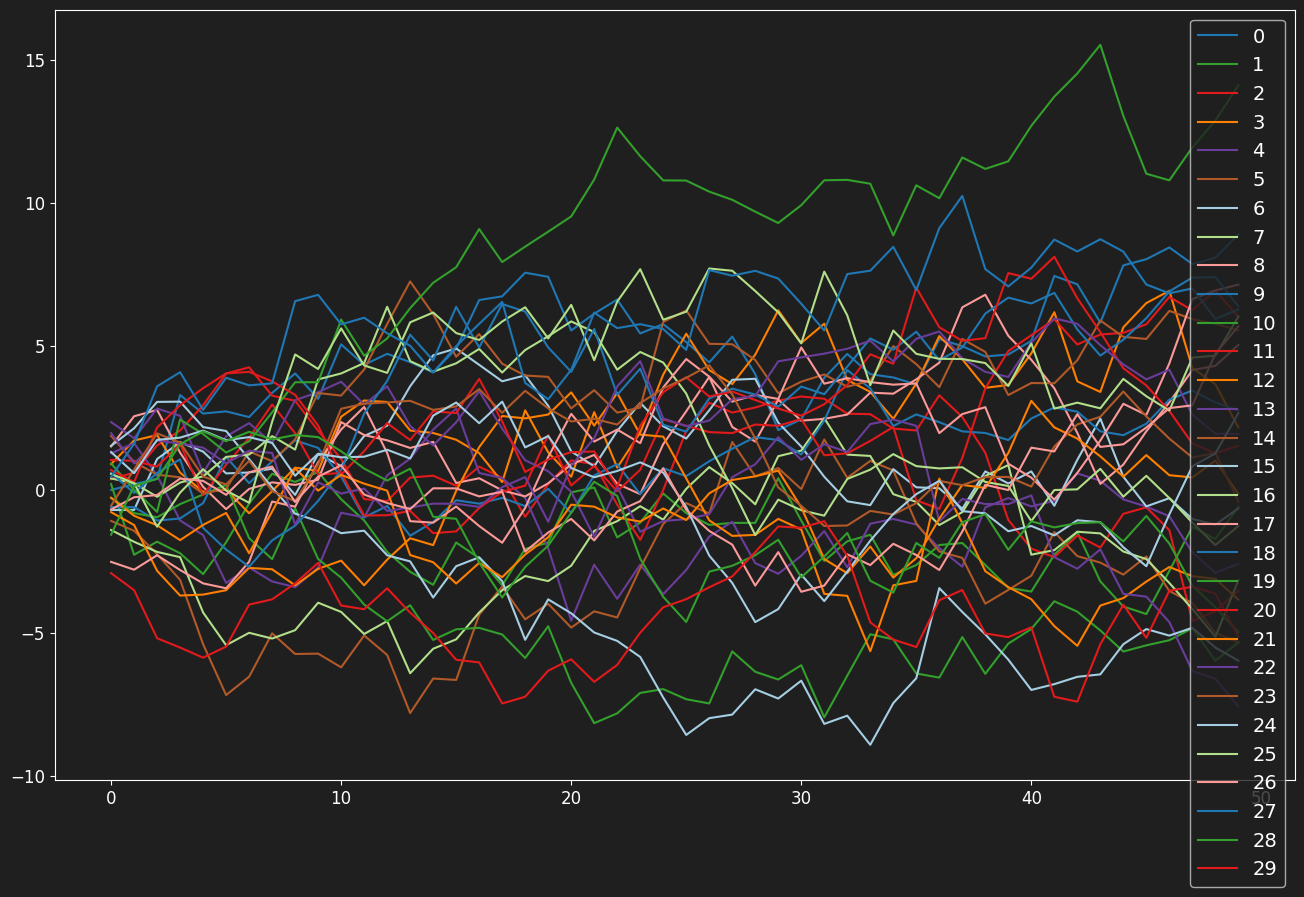

In [23]:
Y.plot()
plt.show()

The variance increases over time, this violates one of the criteria for using OLS - A constant variance. The series tends to move in all sorts of directions. There is no reversion to some well-defined mean, even though all series come from exactly the same process. This is getting closer to the definition of stationarity, and it gives us som intuition on why using a non-stationary series can give misleading results. 

### Stationarity - a bit more formally

Covariance stationarity is defined as when $E(x_t)$ is stable (expected value, mean) and $var(x_t)$ is stable (variance).

Time series that are non-stationary: 
- Time series with a trend (mean is not stable). 
- Very persistent time series (random walk).

If we want to learn something about the behavior of a time series or the interaction of two time series, then those series should be stable over time. 

##### Criteria for stationarity

Data needs to be ordered by time. 'Weak Dependence': $corr(x_t, x_{t + h}) \rightarrow 0$ as $h$ gets big. In essence: correlations between data will go to zero as the distance between datapoints increase. A shock to the system will die out over time and not be permanent.

##### AR(1) process

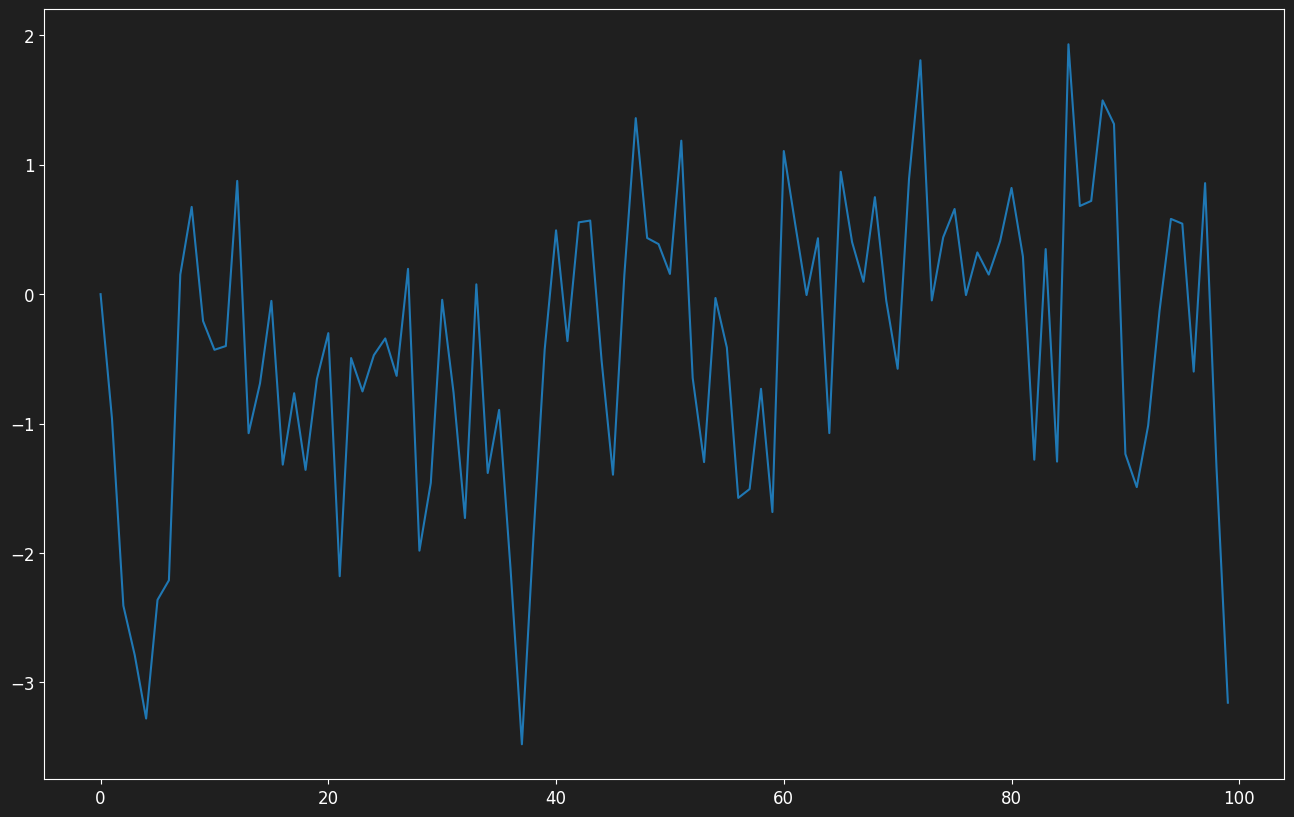

In [24]:
# Looking at a simple AR(1) process: y_t = p * y_(t-1) + e_t, p = .5. Simulating:
T = 100
e = np.random.normal(0, 1, T)
rho = .5 # Autoregressive coefficient.
y = [0] # Initial value of 0

for i in range(T - 1):
    y.append(rho * y[i] + e[i])

y = pd.Series(y)
y.plot()
plt.show()

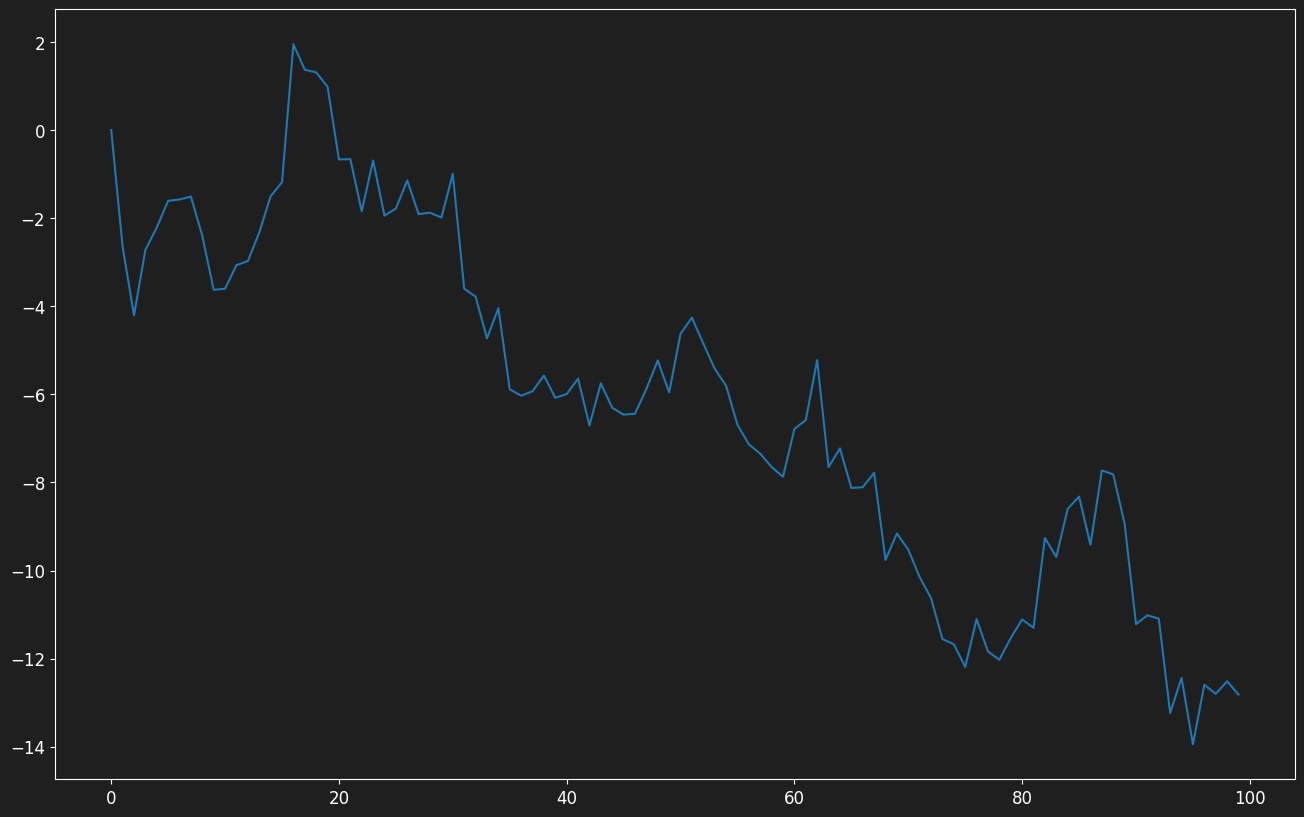

In [25]:
# Setting rho to 1:
T = 100
e = np.random.normal(0, 1, T)
rho = 1 # Autoregressive coefficient.
y = [0] # Initial value of 0

for i in range(T - 1):
    y.append(rho * y[i] + e[i])

y = pd.Series(y)
y.plot()
plt.show()

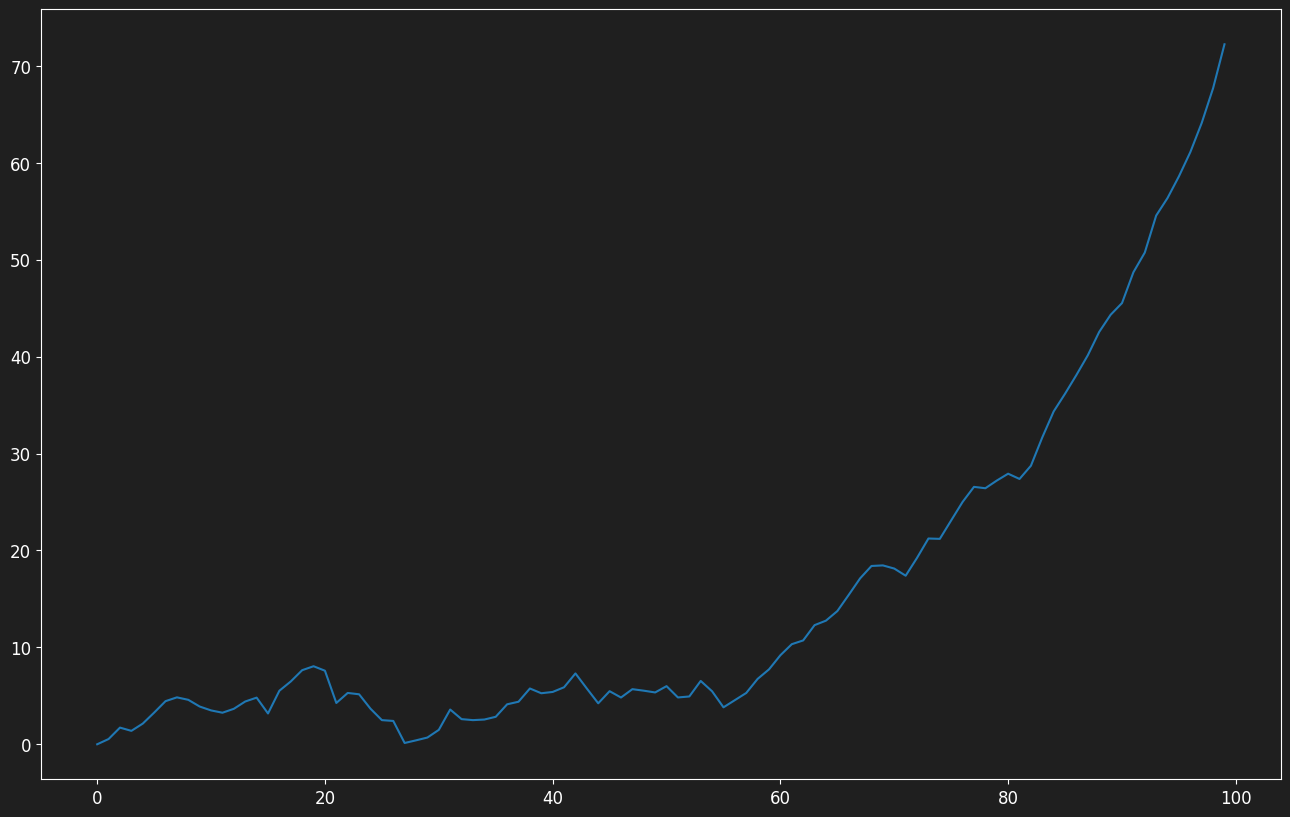

In [26]:
# Setting rho to 1.05 (just over 1):
T = 100
e = np.random.normal(0, 1, T)
rho = 1.05 # Autoregressive coefficient.
y = [0] # Initial value of 0

for i in range(T - 1):
    y.append(rho * y[i] + e[i])

y = pd.Series(y)
y.plot()
plt.show()

The AR model with $|\rho| < 1$ is generally more stable, the series is weakly dependent and stationary.

##### Transformation of highly persistent data

A highly persistent time series, often called I(1) (integrated of order one, or unit-root process). We want I(0): Integrated of order zero process, or a weakly persistent process. 

A good way of transforming an I(1) series, is to take a difference (this will in turn change how we interpret the results).

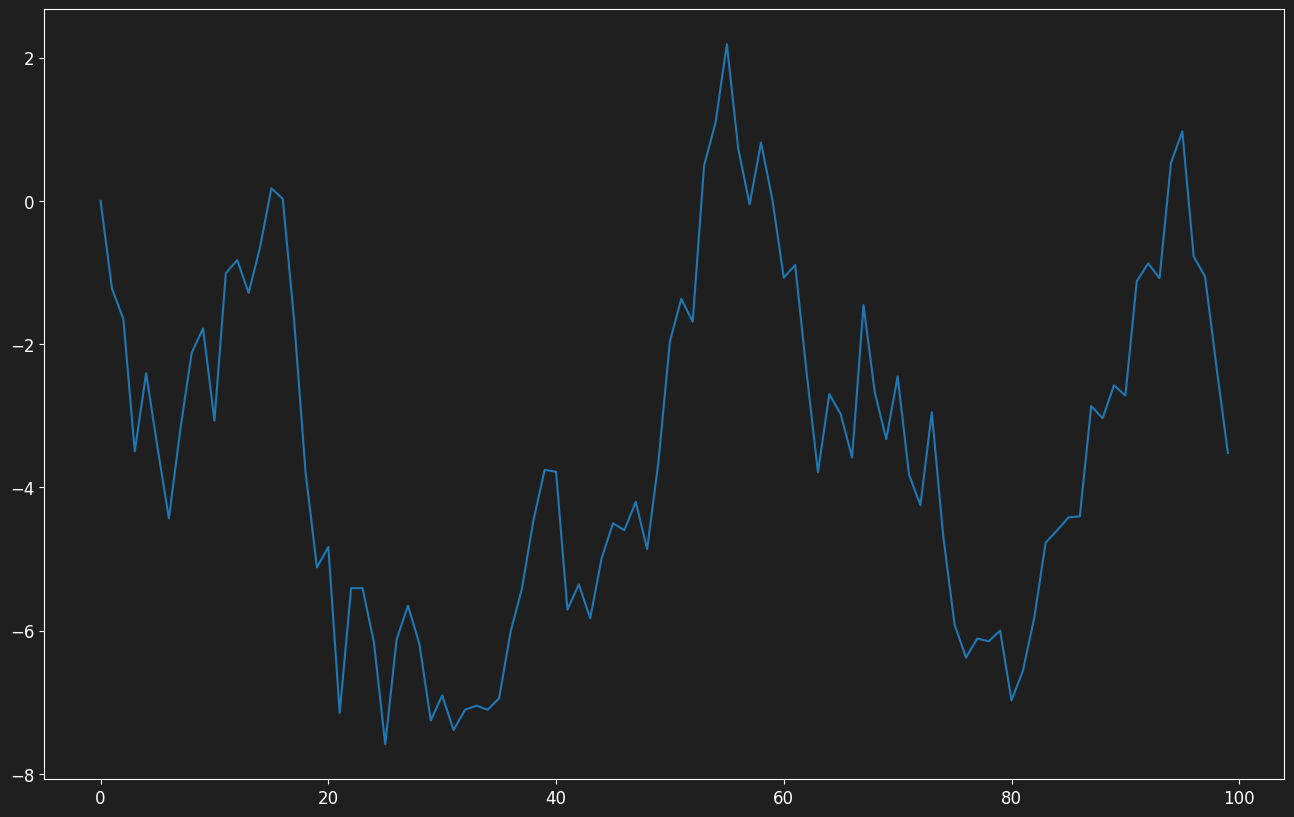

In [27]:
# Generating a random walk series (non-stationary, I(1)):
T = 100
e = np.random.normal(0, 1, T)
rho = 1 # AR coefficient
y = [0]

for i in range(T - 1):
    y.append(rho * y[i] + e[i])

y = pd.Series(y)
y.plot()
plt.show()

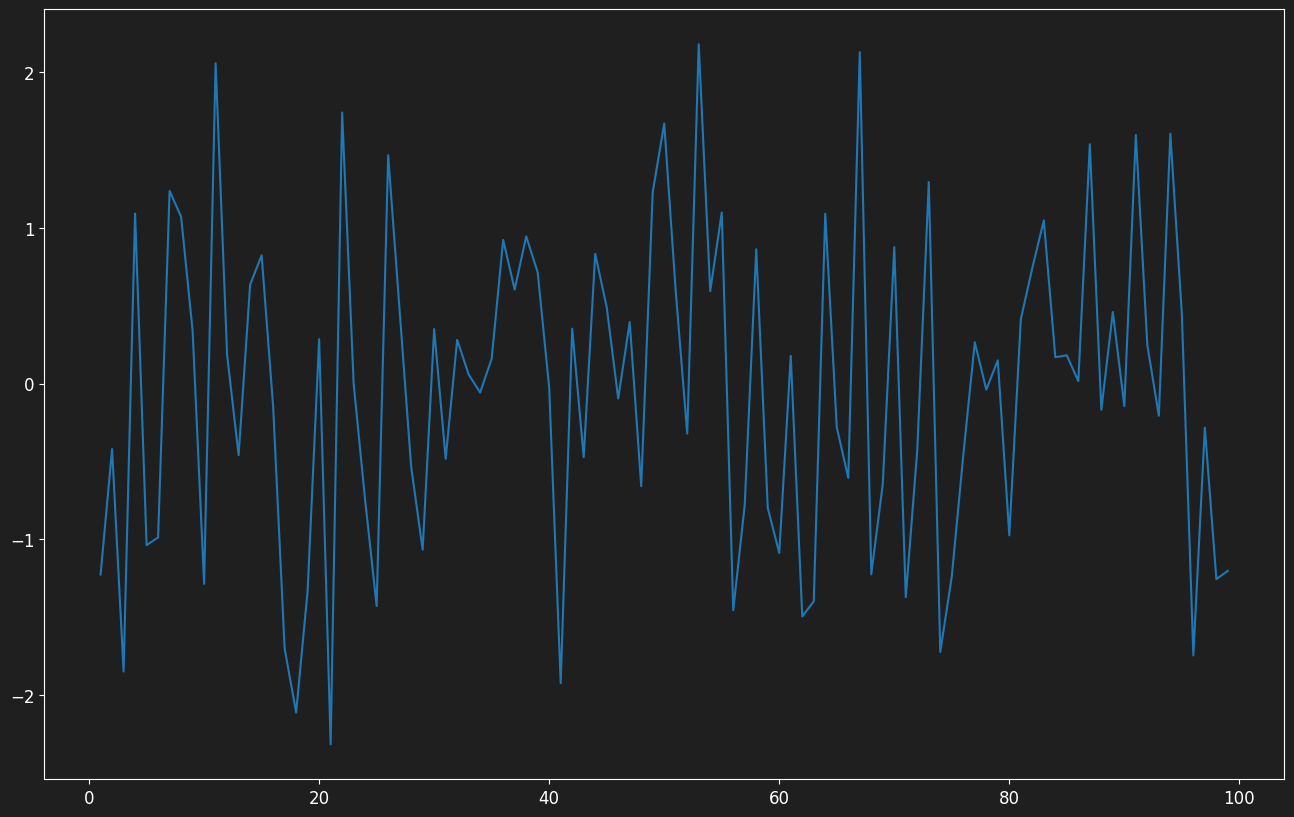

In [28]:
# Transforming by taking the first difference between the current and previous values (using .diff()):
d_y = y.diff()
d_y.plot()
plt.show()

##### Spurious regression

To examplify what can go wrong with non-stationary data, consider a time series model where you regress one series on another. For example two random walks, I will now simulate this:

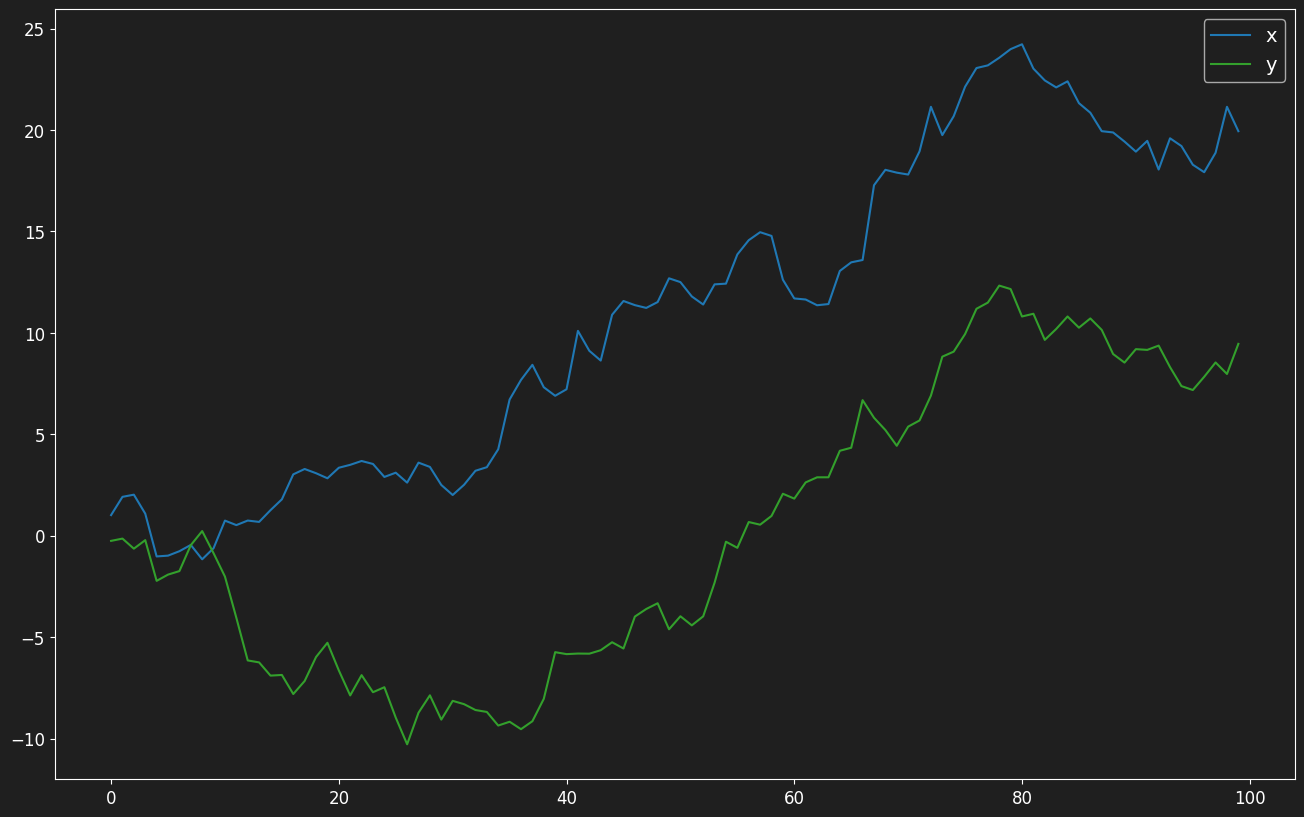

In [48]:
# One simulation to begin with:
T = 100
e = np.random.normal(0, 1, T)
u = np.random.normal(0, 1, T)

x = np.cumsum(e) # Two independent random walks.
y = np.cumsum(u)

spurDF = pd.DataFrame({'x': x, 'y': y})
spurDF.plot()
plt.show()

In [49]:
spurMod = smf.ols('y ~ x - 1', data = spurDF).fit()
spurMod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.273
Model:                            OLS   Adj. R-squared (uncentered):              0.266
Method:                 Least Squares   F-statistic:                              37.25
Date:                Fri, 08 Dec 2023   Prob (F-statistic):                    2.03e-08
Time:                        20:10:32   Log-Likelihood:                         -321.13
No. Observations:                 100   AIC:                                      644.3
Df Residuals:                      99   BIC:                                      646.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              0.2720      0.045      6.103      0.000       0.184       0.360
==============================================================================
Omnibus:                      156.079   Durbin-Watson:                   0.028
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                8.934
Skew:                           0.012   Prob(JB):                       0.0115
Kurtosis:                       1.536   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [50]:
vcov = spurMod.cov_params()
vcov.iloc[0, 0]

0.0019858553583271027

In [52]:
# Doing a monte-carlo simulation and looking at the histogram of simulated b-coefficients:
nsims = 1000
T = 100
bs = []
ses = []

for i in range(nsims):
    e = np.random.normal(0, 1, T)
    u = np.random.normal(0, 1, T)
    x = np.cumsum(e)
    y = np.cumsum(u)
    spurDF = pd.DataFrame({'x': x, 'y': y})
    spurMod = smf.ols('y ~ x - 1', data = spurDF).fit()
    vcov = spurMod.cov_params().iloc[0, 0]
    bs.append(spurMod.params.iloc[0])
    ses.append(np.sqrt(vcov))

bs = pd.Series(bs)
ses = pd.Series(ses)
se_mean = ses.mean()

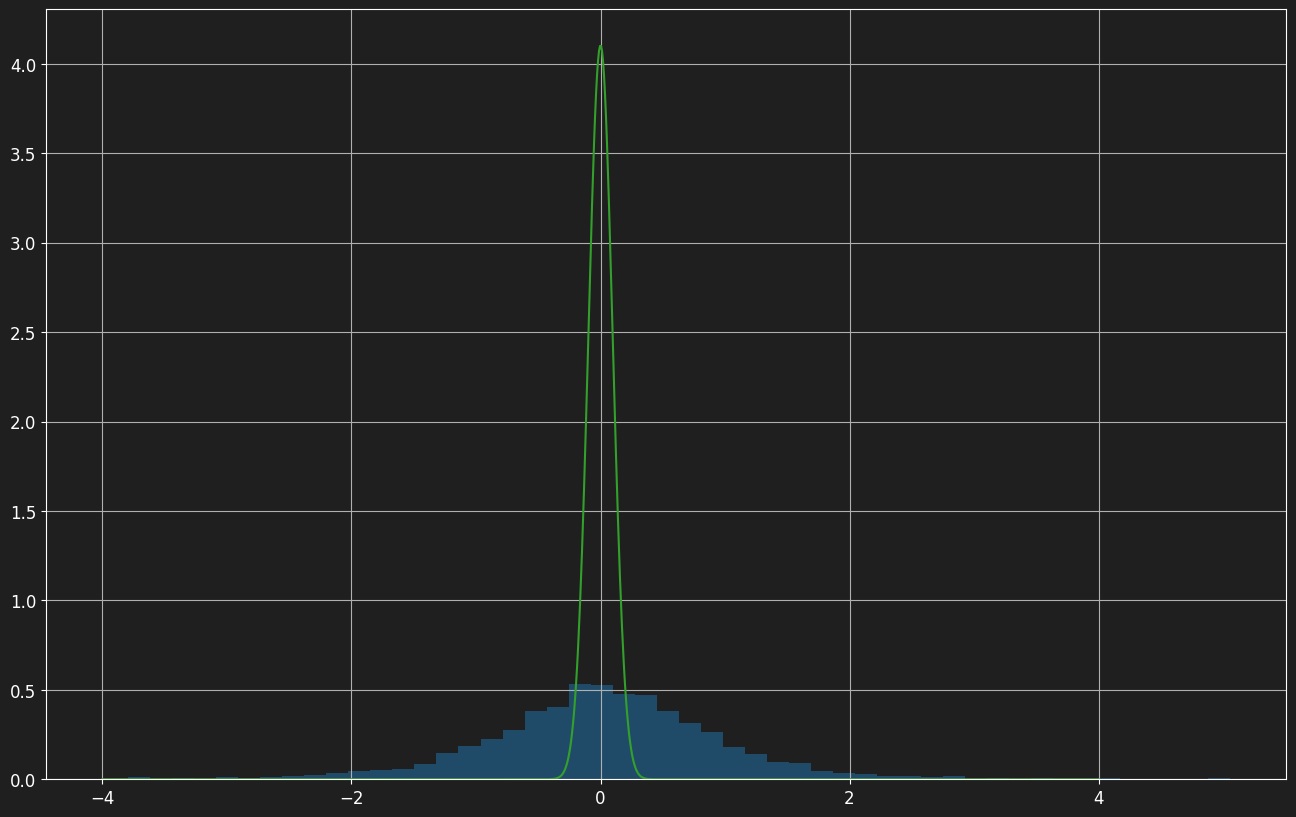

In [59]:
x = np.linspace(-4, 4, nsims)

fig, ax = plt.subplots()
bs.hist(bins = 50, ax = ax, alpha = .5, density = True)
ax.plot(x, spt.norm.pdf(x, 0, se_mean))
plt.show()

This chart shows the distribution of estimated coefficients (blue), compared to what we would expect given the assumption of a normal distribution with a mean of 0 and using the mean of estimated standard errors as the standard deviation. Inference based on standard assumptions when we have non-stationary data will not work at all. 

### Test for I(1)

In [146]:
# A bad way to test for whether a time series is non-stationary, simulating data:
T = 100
e = np.random.normal(0, 1, T)
rho = .8 # AR coefficient.
y = [0]

for i in range(T - 1):
    y.append(rho * y[i] + e[i])

y = pd.Series(y)
Y = pd.DataFrame({'y': y, 'y_l': y.shift()})

arMod2 = smf.ols('y ~ y_l - 1', data = Y).fit()
arMod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.526
Model:                            OLS   Adj. R-squared (uncentered):              0.521
Method:                 Least Squares   F-statistic:                              108.6
Date:                Fri, 08 Dec 2023   Prob (F-statistic):                    1.49e-17
Time:                        20:37:52   Log-Likelihood:                         -136.26
No. Observations:                  99   AIC:                                      274.5
Df Residuals:                      98   BIC:                                      277.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
y_l            0.7305      0.070     10.419      0.000       0.591       0.870
==============================================================================
Omnibus:                        2.023   Durbin-Watson:                   2.179
Prob(Omnibus):                  0.364   Jarque-Bera (JB):                1.826
Skew:                          -0.223   Prob(JB):                        0.401
Kurtosis:                       2.506   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [145]:
# Should get back a coefficient on lag(y) (y_l) that is pretty close to rho (.8). What happens when rho = 1:
T = 100
e = np.random.normal(0, 1, T)
rho = 1 # AR coefficient.
y = [0]

for i in range(T - 1):
    y.append(rho * y[i] + e[i])

y = pd.Series(y)
Y = pd.DataFrame({'y': y, 'y_l': y.shift()})

arMod3 = smf.ols('y ~ y_l - 1', data = Y).fit()
arMod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.650
Model:                            OLS   Adj. R-squared (uncentered):              0.647
Method:                 Least Squares   F-statistic:                              182.1
Date:                Fri, 08 Dec 2023   Prob (F-statistic):                    4.45e-24
Time:                        20:36:28   Log-Likelihood:                         -144.06
No. Observations:                  99   AIC:                                      290.1
Df Residuals:                      98   BIC:                                      292.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
y_l            0.8080      0.060     13.494      0.000       0.689       0.927
==============================================================================
Omnibus:                        0.124   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.940   Jarque-Bera (JB):                0.106
Skew:                          -0.072   Prob(JB):                        0.948
Kurtosis:                       2.929   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Dickey-Fuller test, and augmented 

Null hypothesis is that the model is non-stationary, alternate hypothesis is that the model is stationary.

To take into account more dynamics and serial correlation in a series we use the augmented dickey fuller test. 

##### Testing for stationarity and transforming in practice

In [150]:
# How to use the ADF test:
from statsmodels.tsa.stattools import adfuller

DK1_price = DK_df2['DK1EurMW'].loc[DK_df2['DK1EurMW'].notna()]

In [167]:
adf_test = adfuller(DK1_price, autolag = 'AIC') # autolag: algorithm to find optimal lag length
adf_test

(-9.710211720280785,
 1.0163155629739698e-16,
 49,
 26251,
 {'1%': -3.430599131063867,
  '5%': -2.861650108618613,
  '10%': -2.5668286075580147},
 382593.9686878696)

- 0: Estimated ADF test statistic, the more negative this value, the stronger the evidence against the null hypothesis (non-stationary).
- 1: Estimated p-value, the probability that the null hypothesis (non-stationary) is true.
- 2: The chosen number of lags.
- 3: The number of observations from the data used in the test.
- 4: Dict, critical values associated with different significance levels, compare the ADF Statistic to these critical values. If it's less than the critical value at a specific significance level, you reject the null hypothesis.

If in doubt, it might be best to assume non-stationarity, and transform the data.

##### Serial correlation

When a series is correlated over time, as long as it is stationary, we can still model it without bias. However, if serial correlation is not correctly accounted for, it can lead to standard errors that are no longer 'efficient' (we can no longer count on standard errors and p-values being correct).

In [168]:
# Testing for serial correlation, run a regression with no lags. Look at the residuals of the regression against lagged residuals:
sc_mod = smf.ols('DK1EurMW ~ wind_DK1', data = DK_df2).fit()

resids = sc_mod.resid
fitted = sc_mod.fittedvalues

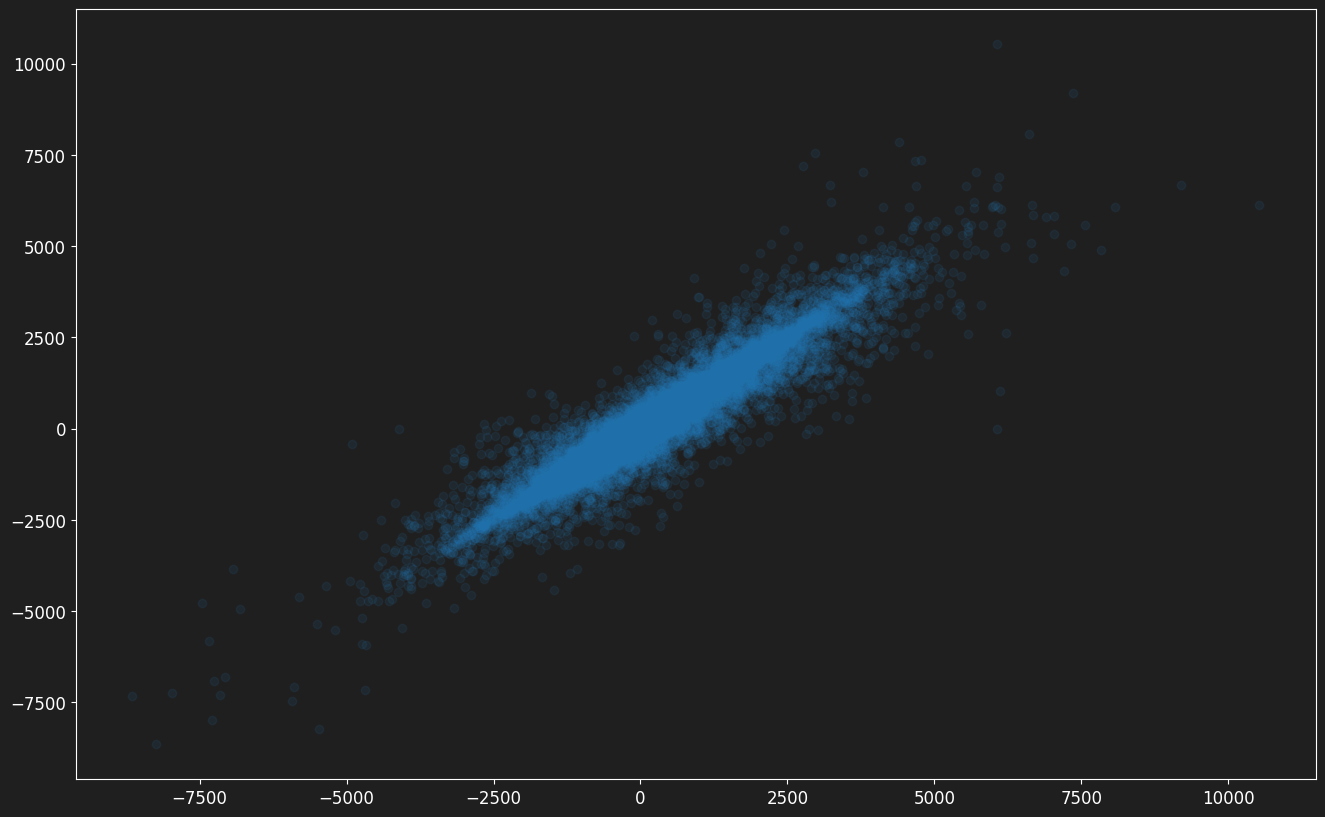

In [169]:
fig, ax = plt.subplots()
ax.scatter(resids, resids.shift(1), alpha = .1)
plt.show()

A clear relationship between the residuals and lagged residuals indicates that there is a good deal of serial correlation in the residuals.

To get a better view of the form of the serial correlation in the data, we can use **Autocorrelation Functions (ACF)** and **Partial Autocorrelation Functions**:

In [170]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [171]:
resids

time
2016-01-01 00:00:00   -1652.490496
2016-01-01 01:00:00   -1711.352990
2016-01-01 02:00:00   -1796.185956
2016-01-01 03:00:00   -1812.678243
2016-01-01 04:00:00   -1868.880094
                          ...     
2018-12-31 19:00:00    2485.596759
2018-12-31 20:00:00    2221.146782
2018-12-31 21:00:00    1795.925540
2018-12-31 22:00:00    1270.260931
2018-12-31 23:00:00      -8.154230
Length: 26301, dtype: float64

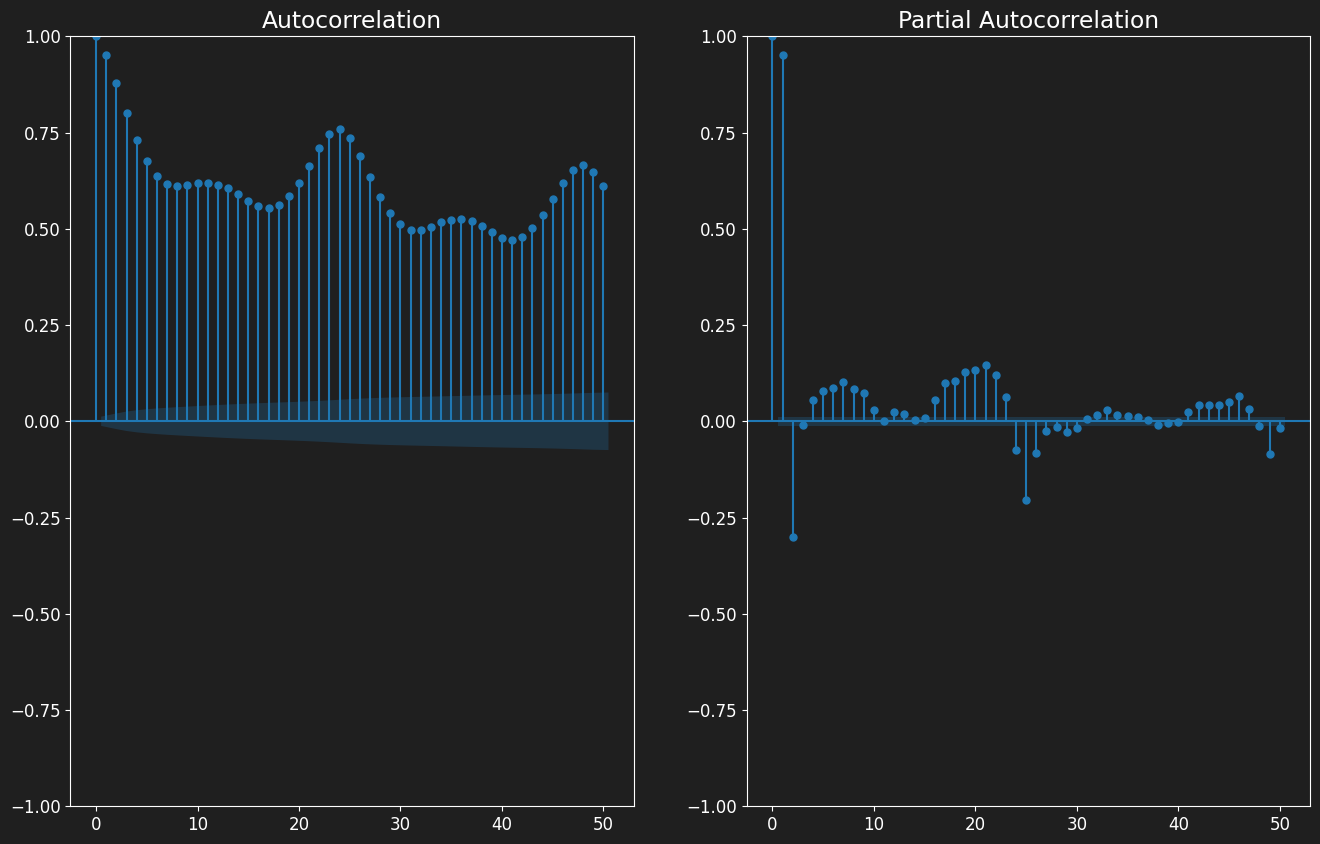

In [172]:
fig, ax = plt.subplots(1, 2)
plot_acf(resids, lags = 50, ax = ax[0])
plot_pacf(resids, lags = 50, ax = ax[1])
plt.show()

- The ACF plot shows the pure correlations between the lags. Here we see strong, long lived correlations. One way to interpret the plot is to say that if we get a shock at time 0 with a magnitude of 1, how big will that shock be in the following periods. 
- The PACF plot shows the correlations between lags, controlling for the intermediate lags. This will be important for establishing the autoregressive nature of the data. 

A few solutions to dealing with serial correlation:
- The first and perhaps best is to try to model the serial explicitly. 
- You could also take a first differnce. This will tend to eliminate a lot of serial correlation (in addition to non-stationarity).

### Summary and preview

Most of time series can be divided into two questions:
- Is the series stable over time (stationary)? If not, making estimates from a limited sample will not be particularily informative, since in the next (unseen) sample period, the time series could look completely different. This is the essence of stationarity. However, if we have a non-stationary series, we can transform it to a stationary series. Here differencing is often a simple and effective strategy. 
- If the series is stationary, what are the dynamics (correlations) like in the series? Model the dynamics in the best possible ways.